In [10]:
import math
import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt

### Simulation of Geometric Brownina motion
A stochastic process follows a Geometric Brownina motion if it satisfies the stochastic differential equation (SDE):
$$dS_t = \mu S_t dt + \sigma S_t dW_t$$

Where $W_t$ is a Brownian motion with $\mu$ being the drift and $\sigma$ is the volatility

The analytical solution is given by: 
$$S_t = S_0 \ exp\left( \left( \mu - \frac{\sigma^2}{2} \right) t + \sigma W_t \right)$$

Specifically we can write $W_t = \sqrt{t} Z$ where $Z\sim N(0, 1)$

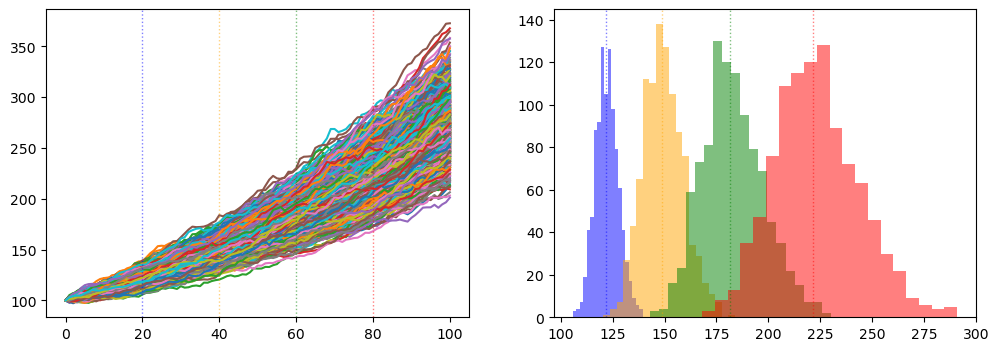

In [8]:
# Simulation of Geometric Brownian paths
S0 = 100
dt = 1
mu = 0.01
sigma = 0.01
steps = 100
nPaths = 1000
S = np.zeros((steps + 1, nPaths))

# Record starting point
S[0] = S0

# Generate paths
for t in range(1, steps+1):
    S[t] = S[t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * np.random.normal(loc=0, scale=1, size=nPaths))


checks = [20, 40, 60, 80]
colors = ['blue', 'orange', 'green', 'red']

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i in range(nPaths):
    ax[0].plot(range(steps+1), S[:, i])

for j,check in enumerate(checks):
    ax[0].axvline(check, lw=1, ls=':', color=colors[j], alpha=0.5)

    motion_mean = S0 * np.exp((mu - 0.5 * sigma**2) * check)
    ax[1].hist(S[check, :], bins=20, color=colors[j], alpha=0.5, label=f'Path distribution at t = {check}')
    ax[1].axvline(motion_mean, lw=1, ls=':', color=colors[j], alpha=0.5)
 
plt.show()


Note that the log of the Geometric Brownian motion has:
- variance given by $Var(\sigma W_t) = \sigma^2 Var(W_t) = \sigma^2 t$
- mean given by $\left( \mu - \frac{\sigma^2}{2} \right) t$

This means that the Geometric Brownina motion has spread given by $\sigma \sqrt{t}$



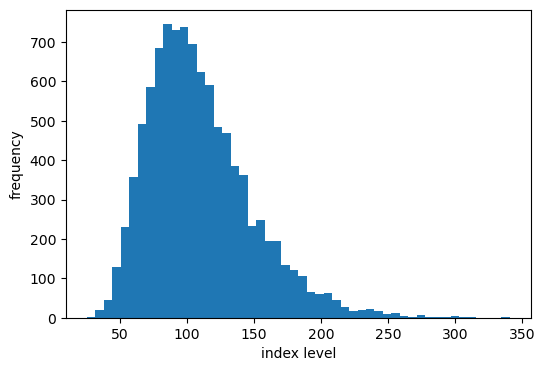

In [24]:
# Simulation of Geometric Brownian motions at a given time
S0 = 100
mu = 0.05
sigma = 0.25
t = 2
nPaths = 10000
ST1 = S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * np.sqrt(t) * np.random.normal(loc=0, scale=1, size=nPaths))


fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.hist(ST1, bins=50)
ax.set_xlabel('index level')
ax.set_ylabel('frequency')
plt.show()

### Checking for normality


In [58]:
# Define some useful methods
def gen_paths(S0, mu, sigma, lastT, nSteps, nPaths):
    '''Generate Geometric Brownian motion paths'''
    dt = lastT / nSteps
    paths = np.zeros((nSteps + 1, nPaths))
    paths[0] = S0 # broadcasting
    for t in range(1, nSteps+1):
        rand = np.random.normal(loc=0, scale=1, size=nPaths)
        rand = (rand - rand.mean()) / rand.std() # step to match first and second moment for generated values
        paths[t] = paths[t-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * rand)
    return paths


def normality_tests(arr):
    '''Set of tests for normality distribution'''

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    sm.qqplot(arr, line='s', ax=ax)
    plt.show()

    print('Skew of data set %14.3f' % scipy.stats.skew(arr))
    print('Skew test p-value %14.3f' % scipy.stats.skewtest(arr)[1])
    print('Kurt of data set %14.3f' % scipy.stats.kurtosis(arr))
    print('Kurt test p-value %14.3f' % scipy.stats.kurtosistest(arr)[1])
    print('Norm test p-value %14.3f' % scipy.stats.normaltest(arr)[1])

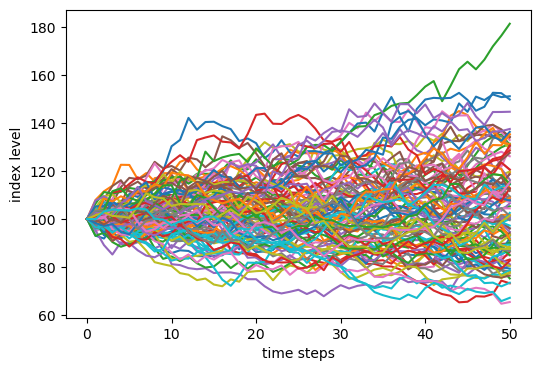

In [60]:
paths = gen_paths(
    S0=100, 
    mu=0.05, 
    sigma=0.2, 
    lastT=1, 
    nSteps=50, 
    nPaths=25000)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(paths[:, :100])
ax.set_xlabel('time steps')
ax.set_ylabel('index level')
plt.show()

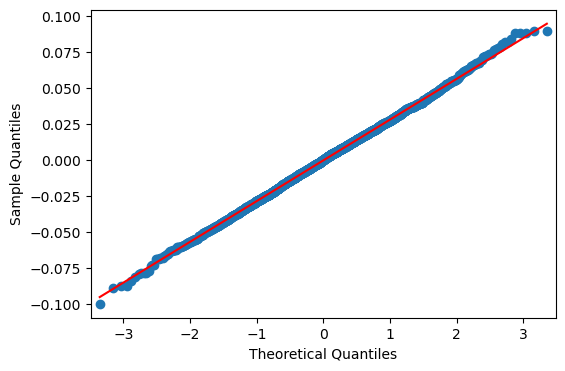

Skew of data set          0.007
Skew test p-value          0.881
Kurt of data set          0.026
Kurt test p-value          0.736
Norm test p-value          0.934


In [64]:
# Annualized log-return
log_returns = np.log(paths[1:] / paths[:-1])

# Test for normality 
normality_tests(log_returns.flatten()[::500])


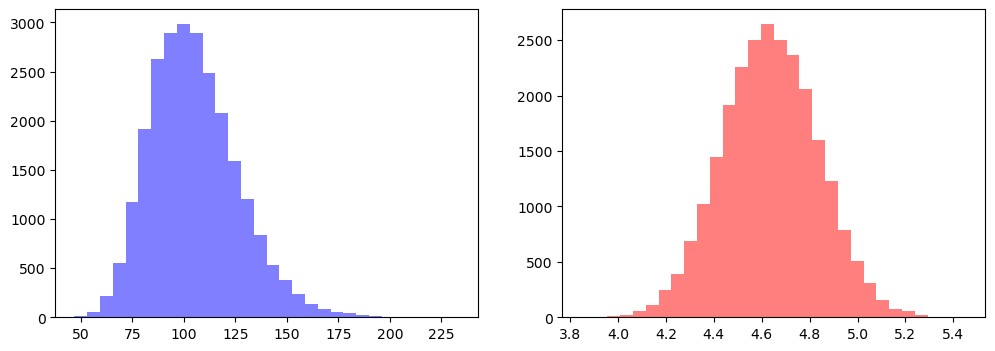

In [67]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(paths[-1], bins=30, alpha=0.5, color='blue')
ax[1].hist(np.log(paths[-1]), bins=30, alpha=0.5, color='red')
plt.show()

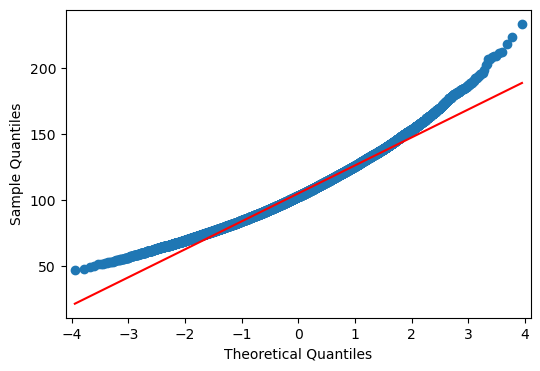

Skew of data set          0.624
Skew test p-value          0.000
Kurt of data set          0.673
Kurt test p-value          0.000
Norm test p-value          0.000


In [68]:
normality_tests(paths[-1])


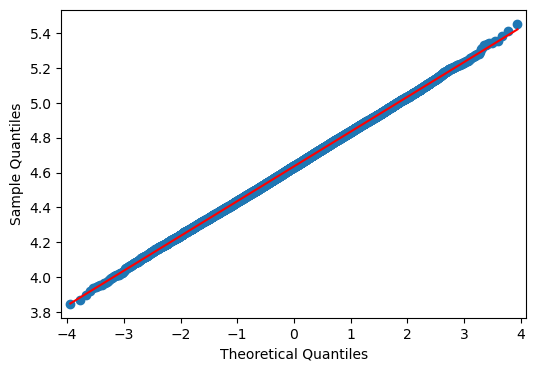

Skew of data set          0.021
Skew test p-value          0.177
Kurt of data set         -0.040
Kurt test p-value          0.195
Norm test p-value          0.173


In [69]:
normality_tests(np.log(paths[-1]))